In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [13]:
df = pd.read_csv("grid_search_results_final.csv")
df["is_gru"] = df["unit_type"].apply(lambda x: 1 if x == "GRU" else 0)
df["is_better_GRU"] = df["better_than_GRU"].apply(lambda x: 1 if x == True else 0)
df["is_better_LSTM"] = df["better_than_LSTM"].apply(lambda x: 1 if x == True else 0)
df["is_better"] = df["is_better_LSTM"] & df["is_better_GRU"]
df

,config_idx,config_name,n_ae_layers,latent_percent,n_header_layers,unit_type,mask_percent,activation,loss,optimizer,...,mae_diff_lstm,better_than_LSTM,baseline_gru_mae,mae_diff_gru,better_than_GRU,status,is_gru,is_better_GRU,is_better_LSTM,is_better
0,13,ae1_lat80_hd2_lstm_m20_relu_adam_lr0.001_bs64_mae,1,0.8,2,LSTM,0.2,relu,mae,adam,...,0.007718,False,0.013116,0.005349,False,success,0,0,0,0
1,1,ae1_lat50_hd1_lstm_m20_relu_adam_lr0.001_bs64_mae,1,0.5,1,LSTM,0.2,relu,mae,adam,...,0.010288,False,0.013116,0.007920,False,success,0,0,0,0
2,15,ae1_lat80_hd2_gru_m20_relu_adam_lr0.001_bs64_mae,1,0.8,2,GRU,0.2,relu,mae,adam,...,0.010741,False,0.013116,0.008373,False,success,1,0,0,0
3,23,ae2_lat50_hd2_gru_m20_relu_adam_lr0.001_bs64_mae,2,0.5,2,GRU,0.2,relu,mae,adam,...,0.011241,False,0.013116,0.008872,False,success,1,0,0,0
4,11,ae1_lat80_hd1_gru_m20_relu_adam_lr0.001_bs64_mae,1,0.8,1,GRU,0.2,relu,mae,adam,...,0.011265,False,0.013116,0.008897,False,success,1,0,0,0
5,12,ae1_lat80_hd1_gru_m80_relu_adam_lr0.001_bs64_mae,1,0.8,1,GRU,0.8,relu,mae,adam,...,0.011328,False,0.013116,0.008959,False,success,1,0,0,0
6,27,ae2_lat80_hd1_gru_m20_relu_adam_lr0.001_bs64_mae,2,0.8,1,GRU,0.2,relu,mae,adam,...,0.011440,False,0.013116,0.009071,False,success,1,0,0,0
7,31,ae2_lat80_hd2_gru_m20_relu_adam_lr0.001_bs64_mae,2,0.8,2,GRU,0.2,relu,mae,adam,...,0.011624,False,0.013116,0.009255,False,success,1,0,0,0
8,16,ae1_lat80_hd2_gru_m80_relu_adam_lr0.001_bs64_mae,1,0.8,2,GRU,0.8,relu,mae,adam,...,0.012394,False,0.013116,0.010025,False,success,1,0,0,0
9,9,ae1_lat80_hd1_lstm_m20_relu_adam_lr0.001_bs64_mae,1,0.8,1,LSTM,0.2,relu,mae,adam,...,0.013504,False,0.013116,0.011135,False,success,0,0,0,0


In [14]:
df.loc[1]

config_idx                                                           1
config_name          ae1_lat50_hd1_lstm_m20_relu_adam_lr0.001_bs64_mae
n_ae_layers                                                          1
latent_percent                                                     0.5
n_header_layers                                                      1
unit_type                                                         LSTM
mask_percent                                                       0.2
activation                                                        relu
loss                                                               mae
optimizer                                                         adam
learning_rate                                                    0.001
batch_size                                                          64
epochs_ae                                                           10
epochs_header                                                       15
test_m

In [15]:
df.columns

Index(['config_idx', 'config_name', 'n_ae_layers', 'latent_percent',
       'n_header_layers', 'unit_type', 'mask_percent', 'activation', 'loss',
       'optimizer', 'learning_rate', 'batch_size', 'epochs_ae',
       'epochs_header', 'test_mae', 'final_ae_loss', 'final_header_loss',
       'baseline_lstm_mae', 'mae_diff_lstm', 'better_than_LSTM',
       'baseline_gru_mae', 'mae_diff_gru', 'better_than_GRU', 'status',
       'is_gru', 'is_better_GRU', 'is_better_LSTM', 'is_better'],
      dtype='object')

In [16]:
independant_variables = [
    'n_ae_layers', 'n_header_layers', 'is_gru', 'mask_percent', 'latent_percent'
]

dependant_variables = [
    'test_mae', 'final_ae_loss', 'final_header_loss', 'is_better', 'is_better_GRU', 'is_better_LSTM'
]

In [17]:
df[independant_variables + dependant_variables]

,n_ae_layers,n_header_layers,is_gru,mask_percent,latent_percent,test_mae,final_ae_loss,final_header_loss,is_better,is_better_GRU,is_better_LSTM
0,1,2,0,0.2,0.8,0.018465,0.025578,0.018465,0,0,0
1,1,1,0,0.2,0.5,0.021036,0.030848,0.021036,0,0,0
2,1,2,1,0.2,0.8,0.021489,0.018242,0.021489,0,0,0
3,2,2,1,0.2,0.5,0.021988,0.023802,0.023486,0,0,0
4,1,1,1,0.2,0.8,0.022013,0.017687,0.022013,0,0,0
5,1,1,1,0.8,0.8,0.022075,0.025804,0.022075,0,0,0
6,2,1,1,0.2,0.8,0.022188,0.019909,0.022188,0,0,0
7,2,2,1,0.2,0.8,0.022372,0.019201,0.022372,0,0,0
8,1,2,1,0.8,0.8,0.023141,0.030322,0.023141,0,0,0
9,1,1,0,0.2,0.8,0.024251,0.026102,0.024251,0,0,0


C:\Users\ajrbe\Documents\School\FoundationalModel\masked-autoencoder-foundation-model-for-oil-and-gas-drilling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ajrbe\Documents\School\FoundationalModel\masked-autoencoder-foundation-model-for-oil-and-gas-drilling\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


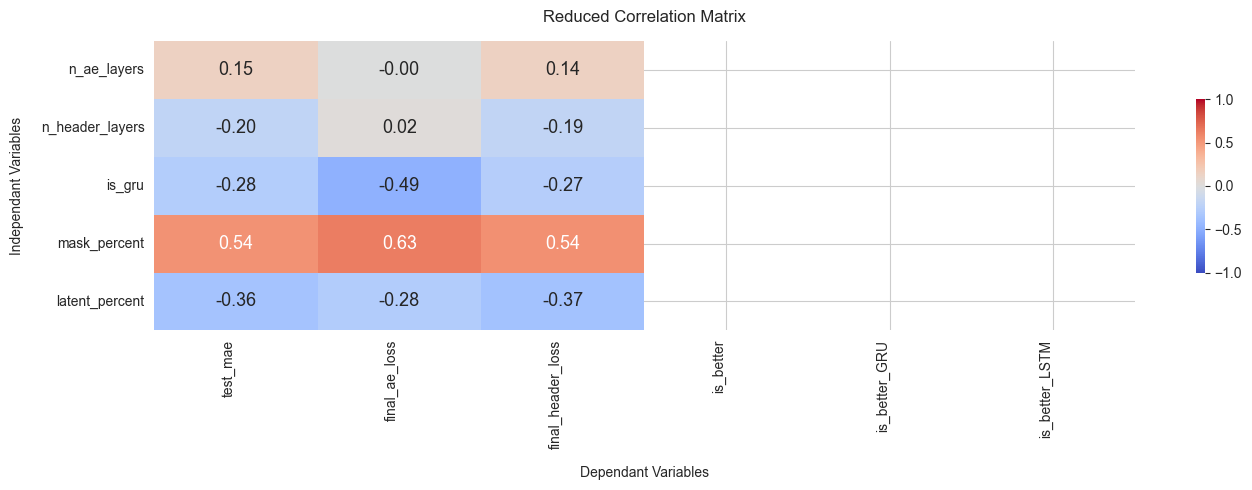

In [18]:
set_bottom = dependant_variables
set_right = independant_variables

A = df[set_right].values
B = df[set_bottom].values

corr = np.corrcoef(A.T, B.T)
corr_mat = corr[:len(set_right), len(set_right):]

corr_df = pd.DataFrame(corr_mat, index=set_right, columns=set_bottom)

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 5))   # wider figure to fit long x-labels

# Plot heatmap
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.6},
    annot_kws={"fontsize": 13}              # reduce annotation font size if crowded
)

# Tweak tick labels so they don't get cut off
ax.set_xlabel("Dependant Variables", labelpad=12)
ax.set_ylabel("Independant Variables", labelpad=12)
ax.set_title("Reduced Correlation Matrix", pad=14)

# Rotate and right-align x tick labels (long names)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)

# Optionally reduce x tick label font size if still crowded
for tick in ax.get_xticklabels():
    tick.set_fontsize(10)

# Tight layout and save without clipping
plt.tight_layout()
plt.savefig("reduced_corr_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

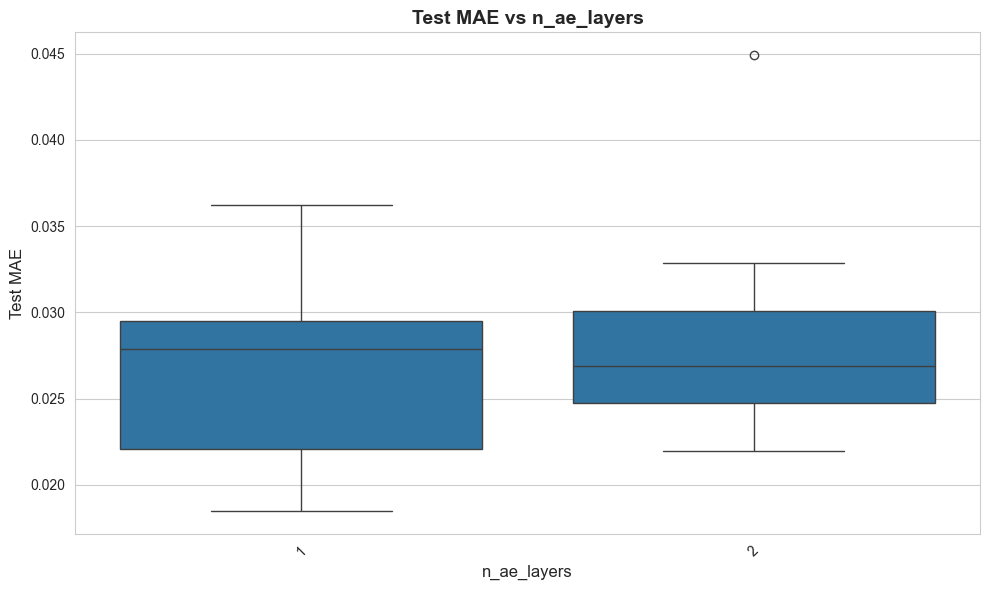

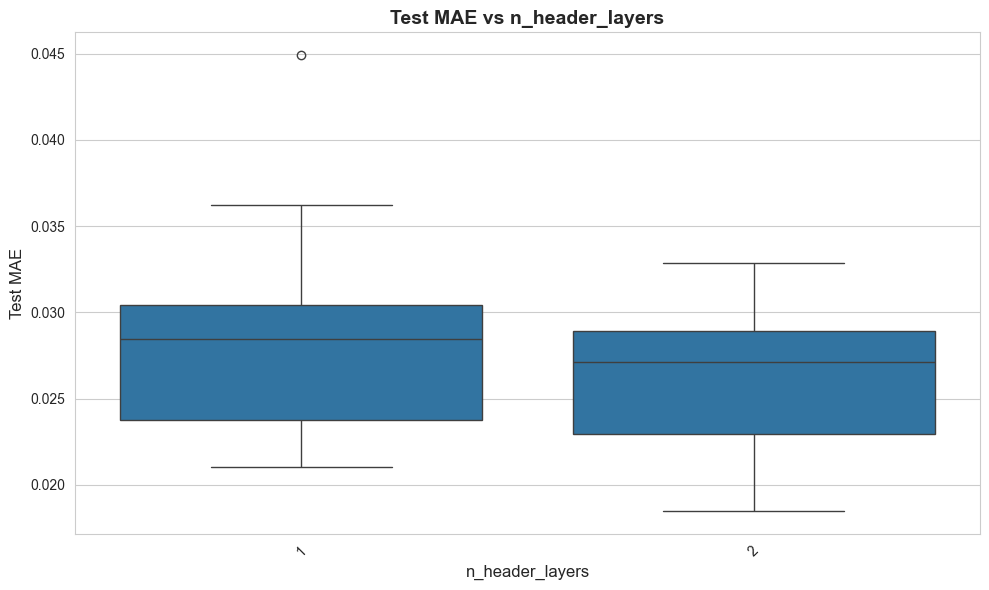

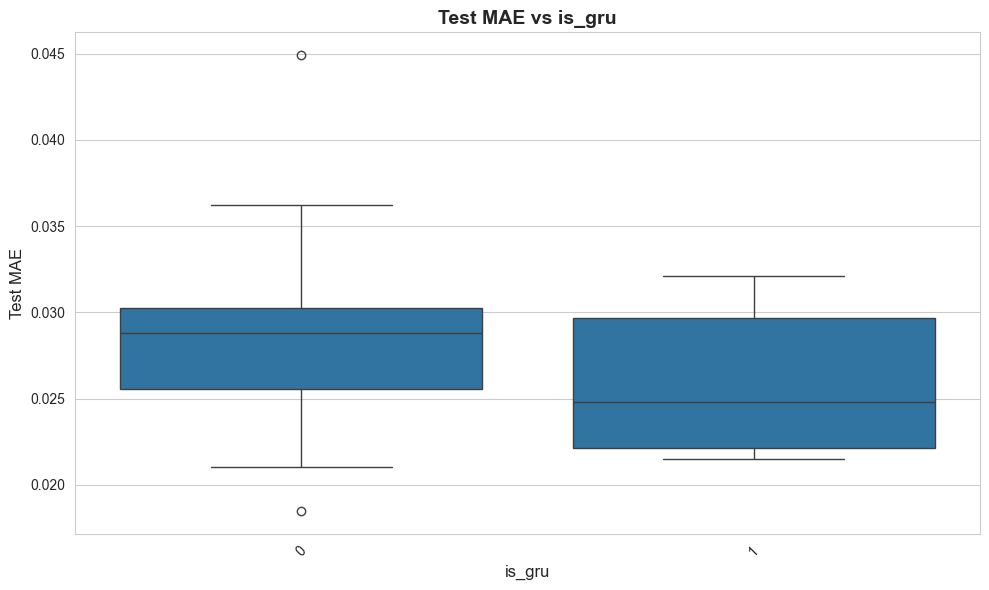

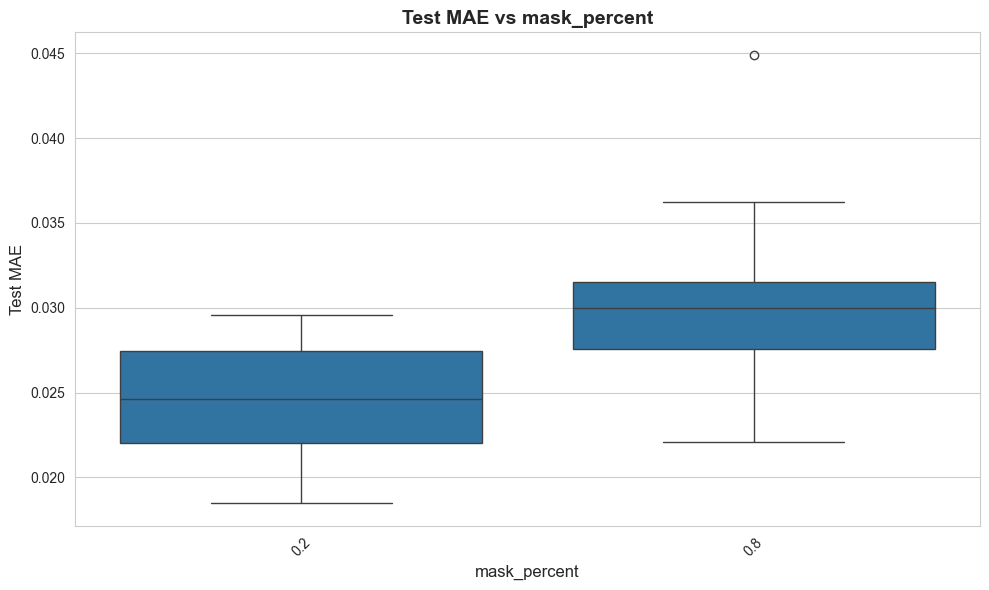

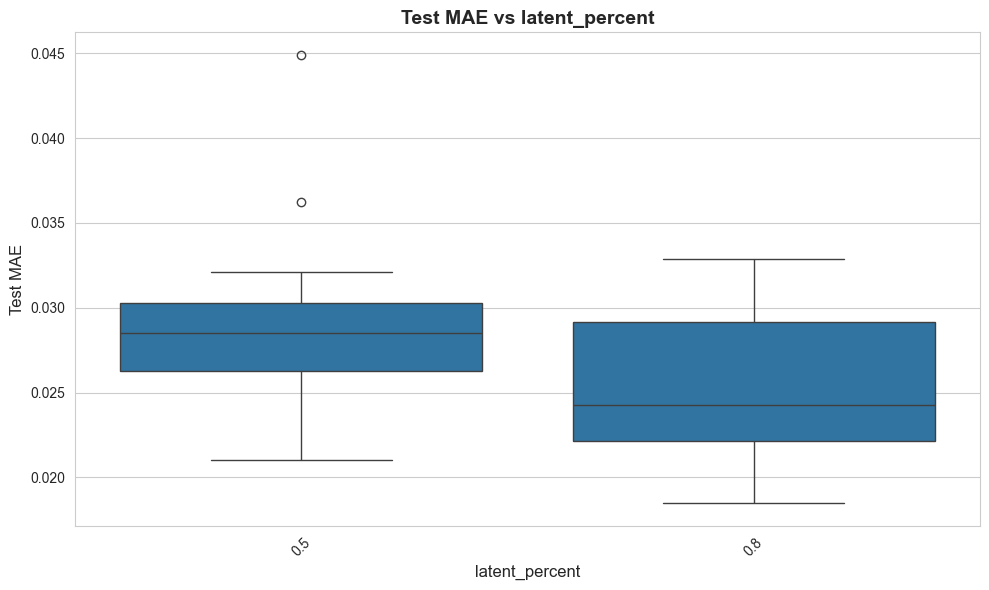

In [19]:
sns.set_style("whitegrid")

for var in independant_variables:
    plt.figure(figsize=(10, 6))
    
    n_unique = df[var].nunique()
    
    if n_unique <= 10:  # Categorical or few unique values
        sns.boxplot(data=df, x=var, y='test_mae')
    else:  # Continuous variable
        sns.scatterplot(data=df, x=var, y='test_mae', alpha=0.6)
        # Add a trend line
        sns.regplot(data=df, x=var, y='test_mae', scatter=False, color='red')
    
    plt.title(f'Test MAE vs {var}', fontsize=14, fontweight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Test MAE', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()